# Imports

In [3]:
import h5py
import numpy as np
import sys

import functools as ft
from sklearn.metrics import RocCurveDisplay, auc, accuracy_score, roc_curve
from sklearn.preprocessing import RobustScaler, PowerTransformer, MinMaxScaler, MaxAbsScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

import copy
from bayes_opt import BayesianOptimization
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR

import torch.nn.functional as F

Possibillities:

    Parameter Optimalization
    Changing Model Architecture
    Change loss function / optimizer

# Data Processing

In [5]:
# g(f(x)) -> F([x, f, g, ...])
F = lambda z: [*ft.reduce(lambda x, y: map(y, x), [z[:1]] + z[1:])][0]

def permutation(*data):
    perm = F([data[0].shape[0], range, np.random.permutation])
    return [x[perm] for x in data]


h5_name = '../Data/4tops_fcn_splitted.h5'

hf = h5py.File(h5_name, 'r')
print(hf.keys())

reg_train = np.array(hf.get("X_train")).astype("float32")#[:1280]
sig_train_label = np.array(hf.get("Y_train")).astype("int8")#[:1280]

print("sig_train_label", sig_train_label)
sig_train = np.where(sig_train_label > 1, 0, sig_train_label)
print("sig_train", sig_train)


reg_train, sig_train = permutation(reg_train, sig_train)


reg_val = np.array(hf.get("X_val")).astype("float32")#[:1280]
sig_val_label = np.array(hf.get("y_val")).astype("int8")#[:1280]

print("sig_val_label", sig_val_label)
sig_val = np.where(sig_val_label > 1, 0, sig_val_label)
print("sig_val", sig_val)


reg_val, sig_val = permutation(reg_val, sig_val)


reg_test = np.array(hf.get("X_test")).astype("float32")#[:1280]
sig_test_label = np.array(hf.get("y_test")).astype("int8")#[:1280]

print("sig_test_label", sig_test_label)
sig_test = np.where(sig_test_label > 1, 0, sig_test_label)
print("sig_test", sig_test)

# reg_test, sig_test = permutation(reg_test, sig_test)

# print(reg_train.shape)
# print(sig_train.shape)
# print(reg_val.shape)
# print(sig_val.shape)
# print(reg_test.shape)
# print(sig_test.shape)

print("reg_train shape", reg_train.shape)
print("reg_train\n", reg_train)

print("sig_train shape", sig_train.shape)
print("sig_train\n", sig_train)

print("reg_val shape", reg_val.shape)
print("reg_val\n", reg_val)

print("sig_val shape", sig_val.shape)
print("sig_val\n", sig_val)

print("reg_test shape", reg_test.shape)
print("reg_test\n", reg_test)

print("sig_test shape", sig_test.shape)
print("sig_test\n", sig_test)


################## useful for plotting, labels per process #####################
# print("sig_train_label shape", sig_train_label.shape)
# print("sig_train_label\n", sig_train_label)

# print("sig_val_label shape", sig_val_label.shape)
# print("sig_val_label\n", sig_val_label)

# print("sig_test_label shape", sig_test_label.shape)
# print("sig_test_label\n", sig_test_label)
#################################################################################


# if you want to save a new .h5 file with labels 0,1 

# ##################### to save the numpy arrays to h5 ###############################

# h5_name = 'data/4tops_fcn_splitted_BC.h5'

# hf = h5py.File(h5_name, 'w')

# hf.create_dataset('reg_train', data=reg_train)
# hf.create_dataset('sig_train', data=sig_train)

# hf.create_dataset('reg_val', data=reg_val)
# hf.create_dataset('sig_val', data=sig_val)

# hf.create_dataset('reg_test', data=reg_test)
# hf.create_dataset('sig_test', data=sig_test)


# hf.create_dataset('sig_train_label', data=sig_train_label)
# hf.create_dataset('sig_val_label', data=sig_val_label)
# hf.create_dataset('sig_test_label', data=sig_test_label)


# hf.close()
# ####################################################################################

<KeysViewHDF5 ['X_test', 'X_train', 'X_val', 'Y_train', 'y_test', 'y_val']>
sig_train_label [4 2 1 ... 1 3 3]
sig_train [0 0 1 ... 1 0 0]
sig_val_label [5 2 1 ... 1 2 5]
sig_val [0 0 1 ... 1 0 0]
sig_test_label [4 3 1 ... 1 1 1]
sig_test [0 0 1 ... 1 1 1]
reg_train shape (241658, 56)
reg_train
 [[ 5.         3.         0.        ... 10.939579  -0.366227  -2.18768  ]
 [ 4.         2.         1.        ...  0.         0.         0.       ]
 [ 4.         4.         0.        ... 10.461637   1.83446   -1.09283  ]
 ...
 [ 5.         2.         1.        ... 13.0463505  0.031635   0.922321 ]
 [ 5.         2.         0.        ... 10.973978   0.544948   1.25061  ]
 [ 5.         3.         1.        ...  0.         0.         0.       ]]
sig_train shape (241658,)
sig_train
 [1 0 1 ... 0 0 1]
reg_val shape (30207, 56)
reg_val
 [[ 4.        2.        1.       ...  0.        0.        0.      ]
 [ 4.        3.        0.       ... 11.786579  0.779339  1.76131 ]
 [ 7.        3.        1.       ... 

In [6]:
# Renaming the datasets to make a bit more sense to me.
X_train, Y_train = reg_train, sig_train
X_val, Y_val = reg_val, sig_val
X_test, Y_test = reg_test, sig_test

# Compute the mean and standard deviation of the training set
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

# Normalize the training set
X_train = (X_train - mean) / std

# Normalize the validation set and test set using the same mean and std as the training set
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

# Define the dataset and dataloaders
train_dataset = TensorDataset(torch.Tensor(X_train), torch.Tensor(Y_train))
val_dataset = TensorDataset(torch.Tensor(X_val), torch.Tensor(Y_val))
test_dataset = TensorDataset(torch.Tensor(X_test), torch.Tensor(Y_test))

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [10]:
# Renaming the datasets to make a bit more sense to me.
X_train_unscaled, Y_train = reg_train, sig_train
print(X_train_unscaled[0])
print(X_train_unscaled[1])
print(X_train_unscaled[2])

print(X_test.shape)
print(Y_test.shape)

#print(X_test[0])

[ 6.         2.         0.         1.         1.         1.
 13.260517   2.3297    13.440902  12.09778   -2.01796    0.353759
 11.908953  11.12687    1.41185   -1.20017   12.218643  11.051187
 -1.83449   -0.281728  11.547713  10.492388  -1.71209   -1.25167
 13.539925  13.452467   0.372474  -0.391643  12.954337  12.557497
 -0.946499   2.43549    0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.        12.897536  12.801268   0.445864  -2.39834
 12.386989  12.079795   0.824508   2.27048   10.739663  10.6210985
 -0.496636   2.78136  ]
[ 8.        2.        0.        1.        0.        1.       12.114746
  1.20027  12.982372 12.695475 -0.778769 -2.11019  12.011425 11.972714
 -0.21211   1.94034  11.852892 11.712612 -0.536187  2.52521  11.207545
 11.156646  0.316353  1.3596   12.740242 12.697076  0.290154 -0.315303
 11.806841 11.773889 -0.167268 -2.32773   0.        0.        0.
  0.        0.        0.        0.        0.        

# Function definitions 

In [7]:
# 23/03 Added early stopping


def train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, num_epochs, patience):
    
    best_val_loss = float('inf')
    best_val_acc = 0.0
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    
    # Early stopping
    epochs_no_improve = 0
    early_stop = False

    for epoch in range(num_epochs):      
        # Training
        model.train()
        running_loss = 0.0
        running_corrects = 0
        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels.long())
            _, preds = torch.max(outputs, 1)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = running_corrects.double() / len(train_loader.dataset)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # Validation
        model.eval()
        running_loss = 0.0
        running_corrects = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels.long())
                _, preds = torch.max(outputs, 1)
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            val_loss = running_loss / len(val_loader.dataset)
            val_acc = running_corrects.double() / len(val_loader.dataset)
            val_losses.append(val_loss)
            val_accs.append(val_acc)

            # Check if this is the best model so far
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1
                
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_weights = copy.deepcopy(model.state_dict())

            # Early stopping
            if epochs_no_improve == patience:
                print(f"Early stopping after {epoch + 1} epochs")
                early_stop = True
                break

        # Update the learning rate scheduler
        scheduler.step(val_loss)

    if early_stop:
        print(f"Stopped at epoch {epoch}")

    # Load the best model weights
    model.load_state_dict(best_model_weights)

    return train_losses, val_losses, train_accs, val_accs, best_val_loss, best_val_acc


In [8]:
def evaluate(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    with torch.no_grad():
        for batch_idx, (data, target) in enumerate(data_loader):
            output = model(data)
            loss = criterion(output, target.unsqueeze(1))
            total_loss += loss.item() * len(data)
            total_correct += ((output >= 0.5).squeeze() == target).sum().item()
    return total_loss / len(data_loader.dataset), total_correct / len(data_loader.dataset)

In [9]:
# GPT-4
def analyze_model(model, criterion, optimizer, scheduler, train_loader, val_loader, test_loader, num_epochs, patience, train):
    
    # Train the model and get the training and validation results (23/03)
    if train == 'yes':
        train_losses, val_losses, train_accs, val_accs, best_val_loss, best_val_acc = train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, num_epochs, patience)
    
    # Prepare to store predictions and ground truth labels
    all_preds = []
    all_labels = []
    
    # 1. Plot the training and validation accuracy versus the epoch number
    plt.figure()
    plt.plot(train_accs, label='Training Accuracy')
    plt.plot(val_accs, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')
    plt.show()
    
    # 2. Plot the training and validation loss versus the epoch number
    plt.figure()
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.show()

    # 3. Calculate the AUC score and 4. Plot the ROC
    model.eval()
            
    with torch.no_grad():
        model.eval()
        all_labels = []
        all_preds = []
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            # Select the predicted scores for the positive class (index 1)
            positive_scores = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(positive_scores)  # Use positive_scores instead of preds
            
    """ GPT4 Replaced following block by the above:
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs)
            probs = torch.sigmoid(outputs).detach().cpu().numpy()
            preds = np.round(probs)
            all_preds.extend(probs)
            all_labels.extend(labels.detach().cpu().numpy())
    """
    
    # 3. Calculate the AUC score
    fpr, tpr, _ = roc_curve(all_labels, all_preds)
    roc_auc = auc(fpr, tpr)

    # 4. Plots the ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.4f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05]) 
    
    #22/03 Had to manually write all the code below bc the bot wouldn't do it for some reason ..
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()
    
    # 5. Print the test accuracy
    test_acc = accuracy_score(labels, preds)
    print(f"Accuracy for model on test set: {test_acc:.4f}")
    print(f"AUC score for model on test set: {roc_auc:.4f}")    

# Model 1: Single Hidden Layer + ReLU.

In [15]:
# Define the model architecture
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.fc1 = nn.Linear(56, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# Define the model, loss function, and optimizer
model = MyModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Train the model with early stopping

train_acc_history = []
val_acc_history = []

best_val_loss = np.inf
patience = 10
counter = 0
num_epochs = 10
weight_decay = 0.001

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels.long())
        
        # Add L2 regularization
        l2_reg = 0.0
        for param in model.parameters():
            l2_reg += torch.norm(param, p=2)**2
        loss += l2_reg * weight_decay
        
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)
    train_loss /= len(train_loader.dataset)

    model.eval()
    val_loss = 0.0
    val_preds = []
    val_labels = []
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels.long())
            val_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, axis=1)
            val_preds += preds.cpu().numpy().tolist()
            val_labels += labels.cpu().numpy().tolist()
        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(val_labels, val_preds)

    print(f'Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

    # Check if the validation loss has improved
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pt')  # save the model weights
    else:
        counter += 1
        if counter >= patience:
            print(f'Validation loss did not improve for {patience} epochs. Stopping early.')
            break
            
print('Finished Training')

# Plot the training and validation accuracies
plt.plot(train_acc_history, label='Train Acc')
plt.plot(val_acc_history, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracies')
plt.legend()
plt.show()

# Save & Load the best model
torch.save(model.state_dict(), 'FCN_001.pt')

In [23]:
# Test the model

model.load_state_dict(torch.load('FCC_001.pt'))

correct = 0
total = 0

X_test = torch.Tensor(X_test)

with torch.no_grad():
    for i in range(len(X_test)):
        inputs = X_test[i]
        labels = Y_test[i]
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 0)
        total += 1
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the test data: %.4f %%' % (
    100.00 * correct / total))

Accuracy of the network on the test data: 74.5026 %


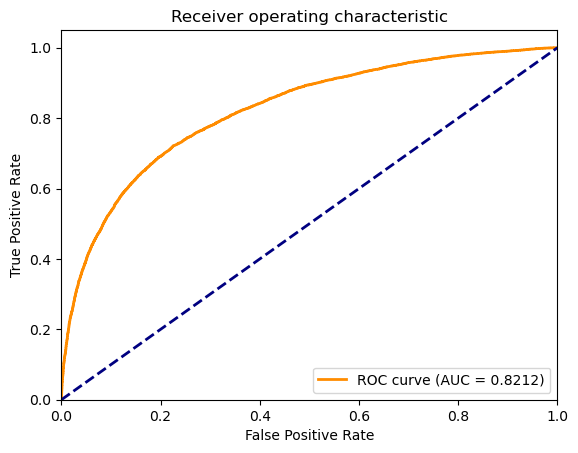

In [21]:
# load the saved PyTorch model
model = MyModel()
model.load_state_dict(torch.load('FCC_001.pt'))

X_test = torch.Tensor(X_test)

# set the model to evaluation mode
model.eval()

# make predictions on the test set
with torch.no_grad():
    y_pred = model(X_test)
    y_scores = torch.softmax(y_pred, dim=1)[:, 1].numpy()
    y_true = Y_test

# calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

print()

# plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()


# Model 2: Activation Function

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
from copy import deepcopy
from tqdm import tqdm

class FCN_ActivationFunction_Loop(nn.Module):
    def __init__(self, activation):
        super(FCN_ActivationFunction_Loop, self).__init__()
        self.fc1 = nn.Linear(56, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)
        if activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'leaky_relu':
            self.activation = nn.LeakyReLU()
        elif activation == 'tanh':
            self.activation = nn.Tanh()
        else:
            raise ValueError("Invalid activation function")
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.dropout(x)
        x = self.activation(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# Define the activation functions to try
activations = ['relu', 'leaky_relu', 'tanh']

# Train the models and select the best performing one based on validation accuracy
best_model = None
best_acc = 0.0
for activation in activations:
    # Initialize the model
    model = FCN_ActivationFunction_Loop(activation)
    
    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Define early stopping
    best_val_acc = 0.0
    early_stopping = 10
    early_stopping_counter = 0

    # Train the model
    print(f"Training model with activation function {activation}")
    for epoch in range(100):
        # Train for one epoch
        model.train()
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            output = model(data)
            target = target.long()
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

        # Evaluate on the validation set
        model.eval()
        val_loss = 0.0
        val_correct = 0
        with torch.no_grad():
            for data, target in val_loader:
                output = model(data)
                target = target.long() # Convert the target tensor to `torch.LongTensor`
                val_loss += criterion(output, target).item()
                pred = output.argmax(dim=1)
                val_correct += pred.eq(target).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)
        
        # Print the validation accuracy for each epoch
        tqdm.write(f"Epoch {epoch + 1}: Validation accuracy = {val_acc:.4f}")

        # Check for early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = deepcopy(model)
            early_stopping_counter = 0
        else:
            early_stopping_counter += 1

        if early_stopping_counter >= early_stopping:
            print(f"Early stopping after {epoch + 1} epochs")
            break
    
    # Save the best performing model
    torch.save(best_model.state_dict(), f"FCN_ActivationFunction_Loop_{activation}.pt")
    print(f"Best validation accuracy for activation function {activation} = {best_val_acc:.4f}")


Training model with activation function relu


RuntimeError: expected scalar type Long but found Float

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score
from copy import deepcopy
from tqdm import tqdm
import matplotlib.pyplot as plt

class FCN_ActivationFunction_Loop(nn.Module):
    def __init__(self, activation):
        super(FCN_ActivationFunction_Loop, self).__init__()
        self.fc1 = nn.Linear(56, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)
        if activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'leaky_relu':
            self.activation = nn.LeakyReLU()
        elif activation == 'tanh':
            self.activation = nn.Tanh()
        else:
            raise ValueError("Invalid activation function")
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.dropout(x)
        x = self.activation(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# Define the activation functions to try
activations = ['relu', 'leaky_relu', 'tanh']

# Train the models and select the best performing one based on validation accuracy
best_models = {}
for activation in activations:
    # Initialize the model
    model = FCN_ActivationFunction_Loop(activation)
    
    # Define the loss function and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Define early stopping
    best_val_acc = 0.0
    early_stopping = 10
    early_stopping_counter = 0

    # Train the model
    print(f"Training model with activation function {activation}")
    for epoch in range(100):
        # Train for one epoch
        model.train()
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            target = target.long() # Convert the target tensor to `torch.LongTensor`
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

        # Evaluate on the validation set
        model.eval()
        val_loss = 0.0
        val_correct = 0
        with torch.no_grad():
            for data, target in val_loader:
                output = model(data)
                target = target.long() # Convert the target tensor to `torch.LongTensor`
                val_loss += criterion(output, target).item()
                pred = output.argmax(dim=1)
                val_correct += pred.eq(target).sum().item()

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)
        
        # Print the validation accuracy for each epoch
        tqdm.write(f"Epoch {epoch + 1}: Validation accuracy = {val_acc:.4f}")

        # Check for early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model = deepcopy(model)
            early_stopping_counter = 0
        else:
            early_stopping_counter += 1

        if early_stopping_counter >= early_stopping:
            print(f"Early stopping after {epoch + 1} epochs")
            break
    
    # Save the best performing model
    best_models[activation] = best_model
    torch.save(best_model.state_dict(), f"FCN_ActivationFunction_Loop_{activation}.pt")
    print(f"Best validation accuracy for activation function {activation} = {best_val_acc:.4f}")


Training model with activation function relu
Epoch 1: Validation accuracy = 0.7442
Epoch 2: Validation accuracy = 0.7474
Epoch 3: Validation accuracy = 0.7494
Epoch 4: Validation accuracy = 0.7496
Epoch 5: Validation accuracy = 0.7517
Epoch 6: Validation accuracy = 0.7500
Epoch 7: Validation accuracy = 0.7523
Epoch 8: Validation accuracy = 0.7529
Epoch 9: Validation accuracy = 0.7523
Epoch 10: Validation accuracy = 0.7526
Epoch 11: Validation accuracy = 0.7521
Epoch 12: Validation accuracy = 0.7522
Epoch 13: Validation accuracy = 0.7521
Epoch 14: Validation accuracy = 0.7521
Epoch 15: Validation accuracy = 0.7518
Epoch 16: Validation accuracy = 0.7517
Epoch 17: Validation accuracy = 0.7511
Epoch 18: Validation accuracy = 0.7518
Early stopping after 18 epochs
Best validation accuracy for activation function relu = 0.7529
Training model with activation function leaky_relu
Epoch 1: Validation accuracy = 0.7454
Epoch 2: Validation accuracy = 0.7457
Epoch 3: Validation accuracy = 0.7478
Epo

ValueError: Found input variables with inconsistent numbers of samples: [241658, 122]

In [ ]:
# load the saved PyTorch model
model = MyModel()
model.load_state_dict(torch.load('FCC_001.pt'))

# set the model to evaluation mode
model.eval()

# make predictions on the test set
with torch.no_grad():
    y_pred = model(X_test)
    y_scores = torch.softmax(y_pred, dim=1)[:, 1].numpy()
    y_true = Y_test

# calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

Accuracy for model with activation function relu on test set: 0.7524
Accuracy for model with activation function leaky_relu on test set: 0.7546
Accuracy for model with activation function tanh on test set: 0.7568


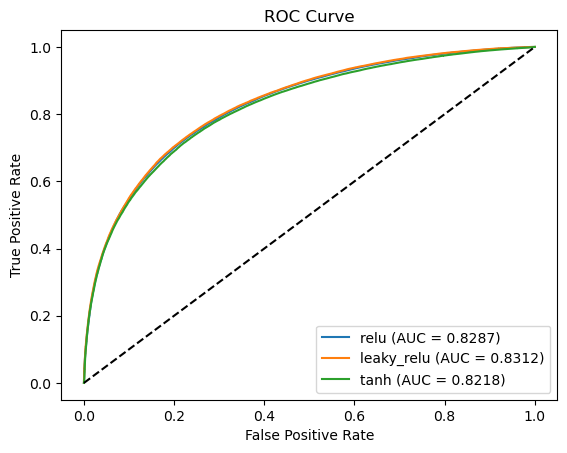

In [45]:
# Test the best model on the test set
for activation in activations:

    # Load the best model
    model = FCN_ActivationFunction_Loop(activation)
    model.load_state_dict(torch.load(f"FCN_ActivationFunction_Loop_{activation}.pt"))

    # Test the model on the test set
    model.eval()
    with torch.no_grad():
        test_pred = []
        test_label = []
        for data, target in test_loader:
            output = model(data)
            pred = output.argmax(dim=1)
            test_pred += pred.cpu().numpy().tolist()
            test_label += target.cpu().numpy().tolist()

    test_acc = accuracy_score(test_label, test_pred)
    print(f"Accuracy for model with activation function {activation} on test set: {test_acc:.4f}")

    # Plot the ROC curve
    model.eval()
    with torch.no_grad():
        test_pred = []
        test_label = []
        output_list = []
        for data, target in test_loader:
            output = model(data)
            output_list.append(output)
            pred = output.argmax(dim=1)
            test_pred += pred.cpu().numpy().tolist()
            test_label += target.cpu().numpy().tolist()

    # Concatenate the outputs to form a single tensor
    output = torch.cat(output_list)

    # Plot the ROC curve
    fpr, tpr, _ = roc_curve(test_label, output[:, 1].cpu().numpy())
    auc = roc_auc_score(test_label, output[:, 1].cpu().numpy())
    plt.plot(fpr, tpr, label=f"{activation} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


### Double Check Results from above

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score
from copy import deepcopy
from tqdm import tqdm
import matplotlib.pyplot as plt

class FCN_ActivationFunction_Loop(nn.Module):
    def __init__(self, activation):
        super(FCN_ActivationFunction_Loop, self).__init__()
        self.fc1 = nn.Linear(56, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 2)
        if activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'leaky_relu':
            self.activation = nn.LeakyReLU()
        elif activation == 'tanh':
            self.activation = nn.Tanh()
        else:
            raise ValueError("Invalid activation function")
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.dropout(x)
        x = self.activation(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# Define the activation functions to try
activations = ['relu', 'leaky_relu', 'tanh']

Accuracy for model with activation function relu on test set: 0.7483
Accuracy for model with activation function leaky_relu on test set: 0.7482
Accuracy for model with activation function tanh on test set: 0.7465


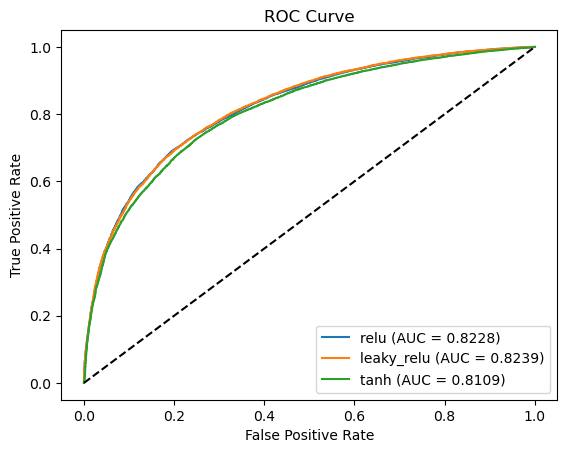

In [16]:
# Test the best model on the test set
for activation in activations:

    # Load the best model
    model = FCN_ActivationFunction_Loop(activation)
    model.load_state_dict(torch.load(f"Activation Function/FCN_ActivationFunction_Loop_{activation}.pt"))

    # Test the model on the test set
    model.eval()
    with torch.no_grad():
        test_pred = []
        test_label = []
        for data, target in test_loader:
            output = model(data)
            pred = output.argmax(dim=1)
            test_pred += pred.cpu().numpy().tolist()
            test_label += target.cpu().numpy().tolist()

    test_acc = accuracy_score(test_label, test_pred)
    print(f"Accuracy for model with activation function {activation} on test set: {test_acc:.4f}")

    # Plot the ROC curve
    model.eval()
    with torch.no_grad():
        test_pred = []
        test_label = []
        output_list = []
        for data, target in test_loader:
            output = model(data)
            output_list.append(output)
            pred = output.argmax(dim=1)
            test_pred += pred.cpu().numpy().tolist()
            test_label += target.cpu().numpy().tolist()

    # Concatenate the outputs to form a single tensor
    output = torch.cat(output_list)

    # Plot the ROC curve
    fpr, tpr, _ = roc_curve(test_label, output[:, 1].cpu().numpy())
    auc = roc_auc_score(test_label, output[:, 1].cpu().numpy())
    plt.plot(fpr, tpr, label=f"{activation} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


# Model 3: LeakyReLU Grid Search

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import copy

# Define the hyperparameters to be searched
learning_rates = [0.001, 0.01, 0.1]
hidden_units = [16, 32, 64]
dropout_rates = [0.2, 0.4, 0.6]

# Define the number of epochs and batch size
num_epochs = 100
batch_size = 128

# Define the patience for early stopping
patience = 10

# Define the activation function
activation_fn = nn.LeakyReLU()

input_size = 56

# Define the model architecture
class FCN_LeakyReLU(nn.Module):
    def __init__(self, hidden_size, dropout_rates):
        super(FCN_LeakyReLU, self).__init__()
        self.fc1 = nn.Linear(56, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 2)
        self.relu = nn.LeakyReLU()
        self.dropout = nn.Dropout(dropout_rates)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [6]:
def train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, num_epochs):
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    best_val_acc = 0.0
    best_model = None

    for epoch in range(num_epochs):
        # Train the model
        model.train()
        running_loss = 0.0
        running_corrects = 0
        for data, target in train_loader:
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target.long()) # 14/03 Manually had to convert to .long
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * data.size(0)
            preds = torch.argmax(output, axis=1)
            running_corrects += torch.sum(preds == target)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = running_corrects / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)

        # Evaluate the model on the validation set
        model.eval()
        running_loss = 0.0
        running_corrects = 0
        for data, target in val_loader:
            output = model(data)
            loss = criterion(output, target.long()) # 14/03 Manually had to convert to .long
            running_loss += loss.item() * data.size(0)
            preds = torch.argmax(output, axis=1)
            running_corrects += torch.sum(preds == target)

        epoch_val_loss = running_loss / len(val_loader.dataset)
        epoch_val_acc = running_corrects / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)
        val_accs.append(epoch_val_acc)

        # Update the scheduler
        scheduler.step(epoch_val_loss) # 16/03 Added epoch_val_loss argument

        # Update the best model if necessary
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            #best_model = copy.deepcopy(model.state_dict())
            print(f"Best validation accuracy for lr={lr}, hu={hu}, dr={dr}: {best_val_acc:.4f}")

    return train_losses, val_losses, train_accs, val_accs

def evaluate_model(model, dataloader, criterion):
    
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    y_true = []
    y_scores = []
    
    with torch.no_grad():
        for data, target in dataloader:
            output = model(data)
            loss = criterion(output, target.long()) # 14/03 Manually had to convert to .long
            _, preds = torch.max(output, 1)
            running_loss += loss.item() * data.size(0)
            running_corrects += torch.sum(preds == target.data)
            y_true.extend(target.data.cpu().numpy())
            y_scores.extend(torch.softmax(output, dim=1)[:, 1].cpu().numpy())

        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = running_corrects.double() / len(dataloader.dataset)
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        epoch_auc = roc_auc_score(y_true, y_scores)

        if epoch_acc > best_accuracy:
            best_accuracy = epoch_acc
            best_model = copy.deepcopy(model.state_dict())

    print(f"Validation Loss: {epoch_loss:.4f} Validation Accuracy: {epoch_acc:.4f} Validation AUC: {epoch_auc:.4f}")
    return epoch_loss, epoch_acc, epoch_auc, best_model



In [8]:
# Define hyperparameters
learning_rates = [1e-8, 0.01, 0.1]
hidden_units = [16, 32, 64]
dropout_rates = [0.2, 0.4, 0.6]

# Create empty lists to store results
best_accuracy = 0.0
best_model = None

best_val_acc = 0.0
best_model = None

# Loop over hyperparameters and train/evaluate models
for lr in learning_rates:
    for hu in hidden_units:
        for dr in dropout_rates:
            
            # Define model architecture with the given hyperparameters                 
            model = FCN_LeakyReLU(hidden_size=hu, dropout_rates=dr)
            criterion = nn.CrossEntropyLoss()
            optimizer = optim.Adam(model.parameters(), lr=lr)
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=5, verbose=True)

            # Train and evaluate the model
            train_losses, val_losses, train_accs, val_accs = train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, num_epochs)

            # Select the best model based on the highest validation set accuracy
            epoch_val_acc = max(val_accs)
            if epoch_val_acc > best_val_acc:
                best_val_acc = epoch_val_acc
                best_model = model.state_dict()

            # Save the model with a unique name based on the hyperparameters
            model_name = f"FCN_LeakyReLU_lr{lr}_hu{hu}_dr{dr}.pt"
            torch.save(model.state_dict(), model_name)

Best validation accuracy for lr=1e-08, hu=16, dr=0.2: 0.4952
Best validation accuracy for lr=1e-08, hu=16, dr=0.2: 0.4952
Best validation accuracy for lr=1e-08, hu=16, dr=0.2: 0.4953
Best validation accuracy for lr=1e-08, hu=16, dr=0.2: 0.4956
Best validation accuracy for lr=1e-08, hu=16, dr=0.2: 0.4957
Best validation accuracy for lr=1e-08, hu=16, dr=0.2: 0.4960
Best validation accuracy for lr=1e-08, hu=16, dr=0.2: 0.4960
Best validation accuracy for lr=1e-08, hu=16, dr=0.2: 0.4962
Best validation accuracy for lr=1e-08, hu=16, dr=0.2: 0.4965
Best validation accuracy for lr=1e-08, hu=16, dr=0.2: 0.4965
Best validation accuracy for lr=1e-08, hu=16, dr=0.2: 0.4966
Best validation accuracy for lr=1e-08, hu=16, dr=0.2: 0.4968
Best validation accuracy for lr=1e-08, hu=16, dr=0.2: 0.4968
Best validation accuracy for lr=1e-08, hu=16, dr=0.2: 0.4970
Best validation accuracy for lr=1e-08, hu=16, dr=0.2: 0.4974
Best validation accuracy for lr=1e-08, hu=16, dr=0.2: 0.4974
Best validation accuracy

AttributeError: 'collections.OrderedDict' object has no attribute 'train_accs'

In [30]:
import torch
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Define lists of hyperparameters to search over
learning_rates = [1e-8, 0.01, 0.1]
hidden_units = [16, 32, 64]
dropout_rates = [0.2, 0.4, 0.6]

criterion = nn.CrossEntropyLoss() # 17/03 Added manually 


for lr in learning_rates:
    for hu in hidden_units:
        for dr in dropout_rates:
            
            # Load the best model
            model = f"FCN_LeakyReLU_lr{lr}_hu{hu}_dr{dr}.pt"
            model.load_state_dict(torch.load(f"FCN_LeakyReLU_lr{lr}_hu{hu}_dr{dr}.pt"))
            
            # Test the model on the test set
            model.eval()
            with torch.no_grad():
                test_pred = []
                test_label = []
            for data, target in test_loader:
                output = model(data)
                pred = output.argmax(dim=1)
                test_pred += pred.cpu().numpy().tolist()
                test_label += target.cpu().numpy().tolist()

        test_acc = accuracy_score(test_label, test_pred)
        print(f"Accuracy for model with activation function {activation} on test set: {test_acc:.4f}")

        # Plot the ROC curve
        model.eval()
        with torch.no_grad():
            test_pred = []
            test_label = []
            output_list = []
            for data, target in test_loader:
                output = model(data)
                output_list.append(output)
                pred = output.argmax(dim=1)
                test_pred += pred.cpu().numpy().tolist()
                test_label += target.cpu().numpy().tolist()

        # Concatenate the outputs to form a single tensor
        output = torch.cat(output_list)

        # Plot the ROC curve
        fpr, tpr, _ = roc_curve(test_label, output[:, 1].cpu().numpy())
        auc = roc_auc_score(test_label, output[:, 1].cpu().numpy())
        plt.plot(fpr, tpr, label=f"{activation} (AUC = {auc:.4f})")

           
# Show the ROC curves for all models
plt.plot([0, 1], [0, 1], 'k--', label='Random guessing')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve for test set')
plt.legend(loc='lower right')
plt.show()


AttributeError: 'str' object has no attribute 'load_state_dict'

In [27]:
model_dict = torch.load(model_file)
print(model_dict.keys())

odict_keys(['fc1.weight', 'fc1.bias', 'fc2.weight', 'fc2.bias', 'fc3.weight', 'fc3.bias'])


In [7]:
# Finding best model of all saved files 
# Doesnt work since we didn't store the correct values during training which took an entire night...

import torch

learning_rates = [1e-8, 0.01, 0.1]
hidden_units = [16, 32, 64]
dropout_rates = [0.2, 0.4, 0.6]

best_val_acc = 0.0
best_model_file = None

for lr in learning_rates:
    for hu in hidden_units:
        for dr in dropout_rates:
            model_file = f"FCN_LeakyReLU_lr{lr}_hu{hu}_dr{dr}.pt"
            model = torch.load(model_file)
            val_acc = model.best_val_acc
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_model_file = model_file

print(f"Best validation accuracy: {best_val_acc:.4f}, Best model file: {best_model_file}")

AttributeError: 'collections.OrderedDict' object has no attribute 'best_val_acc'

In [ ]:
# Plot training and validation accuracy vs. epoch for the best model
train_accs = best_model.train_accs
val_accs = best_model.val_accs
epochs = range(1, len(train_accs) + 1)

plt.plot(epochs, train_accs, label='Training acc')
plt.plot(epochs, val_accs, label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot ROC curve and AUC score for the best model
fpr, tpr, thresholds = roc_curve(targets, probs[:, 1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

# Bayesian Optimizaton 

In [19]:
# FOLLOWING CODE COMES FROM GPT4
class FNC_BC_Bayes1(nn.Module): 
    def __init__(self, dropout_rate, fc1_neurons, fc2_neurons):
        super(FNC_BC_Bayes1, self).__init__()
        self.fc1 = nn.Linear(56, fc1_neurons)
        self.fc2 = nn.Linear(fc1_neurons, fc2_neurons)
        self.fc3 = nn.Linear(fc2_neurons, 2)
        self.relu = nn.ReLU() #22/03 Forgot to change to leaky relu!
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [21]:
# GPT-4
# Set the bounds for the hyperparameters
bounds = {
    'dropout_rate': (0.1, 0.5),
    'learning_rate': (1e-4, 1e-2),
    'fc1_neurons': (32, 128),
    'fc2_neurons': (16, 64)
}

#21/03 Added manually:
num_epochs = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the Bayesian Optimization object
optimizer = BayesianOptimization(f=optimize_nn, pbounds=bounds, random_state=42)
criterion = nn.CrossEntropyLoss()
optimizer.maximize(init_points=5, n_iter=20)
best_params = optimizer.max['params']

def optimize_nn(dropout_rate, learning_rate, fc1_neurons, fc2_neurons):
    # Convert neuron numbers to integers
    fc1_neurons = int(fc1_neurons)
    fc2_neurons = int(fc2_neurons)

    # Instantiate the model with the new hyperparameters
    model = FNC_BC_Bayes1(dropout_rate, fc1_neurons, fc2_neurons)

    # Define the optimizer with the new learning rate
    pytorch_optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Initialize the scheduler with the PyTorch optimizer
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(pytorch_optimizer, mode='max', factor=0.1, patience=5, verbose=True)

    # Train the model (use your existing 'train_model' function)
    train_losses, val_losses, train_accs, val_accs, best_val_loss, best_val_acc = train_model(model, criterion, pytorch_optimizer, scheduler, train_loader, val_loader, num_epochs)
       
    # Return the best validation accuracy
    return best_val_acc

|   iter    |  target   | dropou... | fc1_ne... | fc2_ne... | learni... |
-------------------------------------------------------------------------
Epoch 00011: reducing learning rate of group 0 to 6.0267e-04.
Epoch 00017: reducing learning rate of group 0 to 6.0267e-05.
Epoch 00023: reducing learning rate of group 0 to 6.0267e-06.
Epoch 00029: reducing learning rate of group 0 to 6.0267e-07.
Epoch 00035: reducing learning rate of group 0 to 6.0267e-08.
Epoch 00041: reducing learning rate of group 0 to 6.0267e-09.
| 1         | 0.7515    | 0.2498    | 123.3     | 51.14     | 0.006027  |
Epoch 00008: reducing learning rate of group 0 to 8.6751e-04.
Epoch 00014: reducing learning rate of group 0 to 8.6751e-05.
Epoch 00020: reducing learning rate of group 0 to 8.6751e-06.
Epoch 00026: reducing learning rate of group 0 to 8.6751e-07.
Epoch 00032: reducing learning rate of group 0 to 8.6751e-08.
Epoch 00038: reducing learning rate of group 0 to 8.6751e-09.
| 2         | 0.752     | 0.1624  

KeyError: 0

In [25]:
print(best_params)
type(best_params)

{'dropout_rate': 0.18248049354424062, 'fc1_neurons': 125.11252181737274, 'fc2_neurons': 16.68813369766123, 'learning_rate': 0.0007876632307562362}


dict

In [45]:
# BEST PARAMS: {'dropout_rate': 0.18248049354424062, 'fc1_neurons': 125.11252181737274, 'fc2_neurons': 16.68813369766123, 'learning_rate': 0.0007876632307562362}

# Have to retrain the model with the best parameters because I forgot to save the best performing model.
dr = best_params["dropout_rate"]
lr = best_params["learning_rate"]
fc1 = int(best_params["fc1_neurons"])
fc2 = int(best_params["fc2_neurons"])
num_epochs = 100

# Initialize the Model
model = FNC_BC_Bayes1(dr, fc1, fc2)
pytorch_optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(pytorch_optimizer, mode='max', factor=0.1, patience=5, verbose=True)

train_losses, val_losses, train_accs, val_accs, best_val_loss, best_val_acc = train_model(model, 
                                                                                          criterion, 
                                                                                          optimizer=pytorch_optimizer, 
                                                                                          scheduler=scheduler, 
                                                                                          train_loader=train_loader, 
                                                                                          val_loader=val_loader, 
                                                                                          num_epochs=num_epochs)

# Save the model with a unique name based on the hyperparameters
torch.save(model.state_dict(), f"FCN_BO_ReLU_dr{dr}_lr{lr}_Neurons{fc1}_{fc2}.pt")



Epoch 00007: reducing learning rate of group 0 to 7.8766e-05.
Epoch 00013: reducing learning rate of group 0 to 7.8766e-06.
Epoch 00019: reducing learning rate of group 0 to 7.8766e-07.
Epoch 00025: reducing learning rate of group 0 to 7.8766e-08.
Epoch 00031: reducing learning rate of group 0 to 7.8766e-09.


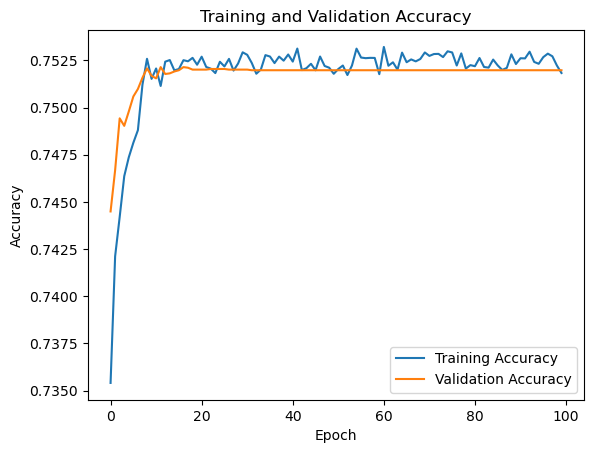

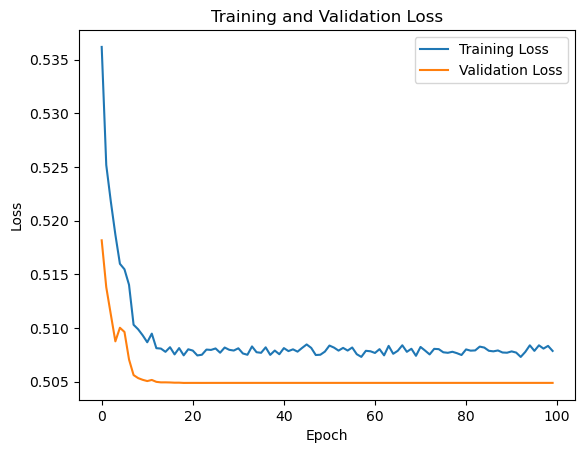

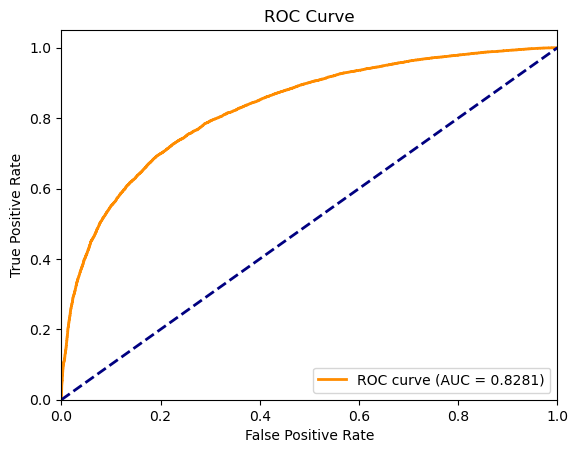

Accuracy for model on test set: 0.7638
AUC score for model on test set: 0.8281


In [64]:
# DO NOT RUN AGAIN!!! (added L2 regularisation after training this model to the training function)
#analyze_model(model, criterion, optimizer, scheduler, train_loader, val_loader, test_loader, num_epochs)

In [58]:
print(roc_auc)

NameError: name 'roc_auc' is not defined

# Bayesian Optimisation "Complex" Model (GPT-4)

In [27]:
class FCN_BC_Bayes2Complex(nn.Module):
    def __init__(self, dropout_rate, fc1_neurons, fc2_neurons, fc3_neurons, fc4_neurons, fc5_neurons, activation_function):
        super(FCN_BC_Bayes2Complex, self).__init__()
        self.fc1 = nn.Linear(56, fc1_neurons)
        self.fc2 = nn.Linear(fc1_neurons, fc2_neurons)
        self.fc3 = nn.Linear(fc2_neurons, fc3_neurons)
        self.fc4 = nn.Linear(fc3_neurons, fc4_neurons)
        self.fc5 = nn.Linear(fc4_neurons, fc5_neurons)
        self.fc6 = nn.Linear(fc5_neurons, 2)
        
        self.bn1 = nn.BatchNorm1d(fc1_neurons)
        self.bn2 = nn.BatchNorm1d(fc2_neurons)
        self.bn3 = nn.BatchNorm1d(fc3_neurons)
        self.bn4 = nn.BatchNorm1d(fc4_neurons)
        self.bn5 = nn.BatchNorm1d(fc5_neurons)
        
        self.dropout = nn.Dropout(dropout_rate)
        
        if activation_function == 'leaky_relu':
            self.activation = F.leaky_relu
        elif activation_function == 'sigmoid':
            self.activation = torch.sigmoid
        elif activation_function == 'tanh':
            self.activation = torch.tanh
        else:
            raise ValueError("Unsupported activation function")

    def forward(self, x):
        x = self.activation(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.activation(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = self.activation(self.bn3(self.fc3(x)))
        x = self.dropout(x)
        x = self.activation(self.bn4(self.fc4(x)))
        x = self.dropout(x)
        x = self.activation(self.bn5(self.fc5(x)))
        x = self.dropout(x)
        x = self.fc6(x)
        return x

In [32]:
# Combination of GPT-4 and manual

# Define the hyperparameter bounds
bounds = {
    'dropout_rate': (0.1, 0.5),
    'learning_rate': (1e-5, 1e-2),
    'l2_lambda': (1e-5, 1e-1),
    'fc1_neurons': (32, 256),
    'fc2_neurons': (32, 256),
    'fc3_neurons': (16, 128),
    'fc4_neurons': (16, 128),
    'fc5_neurons': (8, 64),
    'activation_idx': (0, 2)
}

num_epochs = 100
patience = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def optimize_nn2(dropout_rate, learning_rate, l2_lambda, fc1_neurons, fc2_neurons, fc3_neurons, fc4_neurons, fc5_neurons, activation_idx):
    activation_functions = ['leaky_relu', 'sigmoid', 'tanh']
    activation_function = activation_functions[int(activation_idx)]
    
    # Convert neuron numbers to integers
    fc1_neurons = int(fc1_neurons)
    fc2_neurons = int(fc2_neurons)
    fc3_neurons = int(fc3_neurons)
    fc4_neurons = int(fc4_neurons)
    fc5_neurons = int(fc5_neurons)

    # Instantiate the model with the new hyperparameters
    model = FCN_BC_Bayes2Complex(dropout_rate, fc1_neurons, fc2_neurons, fc3_neurons, fc4_neurons, fc5_neurons, activation_function)
    pytorch_optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=l2_lambda)

    # Initialize the scheduler with the PyTorch optimizer
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(pytorch_optimizer, mode='max', factor=0.1, patience=5, verbose=True)

    # Train the model (use your existing 'train_model' function)
    train_losses, val_losses, train_accs, val_accs, best_val_loss, best_val_acc = train_model(model, criterion, pytorch_optimizer, scheduler, train_loader, val_loader, num_epochs, patience)
       
    # Return the best validation accuracy
    return best_val_acc

# Initialize the Bayesian Optimization object
optimizer = BayesianOptimization(f=optimize_nn2, pbounds=bounds, random_state=42)
criterion = nn.CrossEntropyLoss()
optimizer.maximize(init_points=5, n_iter=20)
best_params = optimizer.max['params']

print(best_params)

|   iter    |  target   | activa... | dropou... | fc1_ne... | fc2_ne... | fc3_ne... | fc4_ne... | fc5_ne... | l2_lambda | learni... |
-------------------------------------------------------------------------------------------------------------------------------------
Epoch 00009: reducing learning rate of group 0 to 6.0151e-04.
Epoch 00015: reducing learning rate of group 0 to 6.0151e-05.
Early stopping!
Stopped at epoch 20
| 1         | 0.5054    | 0.7491    | 0.4803    | 196.0     | 166.1     | 33.47     | 33.47     | 11.25     | 0.08662   | 0.006015  |
Epoch 00008: reducing learning rate of group 0 to 5.2523e-04.
Epoch 00014: reducing learning rate of group 0 to 5.2523e-05.
Early stopping!
Stopped at epoch 19
| 2         | 0.5054    | 1.416     | 0.1082    | 249.3     | 218.5     | 39.78     | 36.36     | 18.27     | 0.03043   | 0.005252  |
Epoch 00011: reducing learning rate of group 0 to 2.0047e-04.
Epoch 00017: reducing learning rate of group 0 to 2.0047e-05.
Epoch 00023: reducin

In [33]:
print(best_params)

{'activation_idx': 0.28846367919276505, 'dropout_rate': 0.20605493182935702, 'fc1_neurons': 249.9395487131346, 'fc2_neurons': 248.68629389730773, 'fc3_neurons': 86.59067998467215, 'fc4_neurons': 28.084181586403805, 'fc5_neurons': 56.6380700092903, 'l2_lambda': 0.0012090876250252234, 'learning_rate': 0.00918721747271677}


Epoch 00009: reducing learning rate of group 0 to 9.1872e-04.
Epoch 00015: reducing learning rate of group 0 to 9.1872e-05.
Epoch 00021: reducing learning rate of group 0 to 9.1872e-06.
Epoch 00027: reducing learning rate of group 0 to 9.1872e-07.
Epoch 00033: reducing learning rate of group 0 to 9.1872e-08.
Early stopping!
Stopped at epoch 35


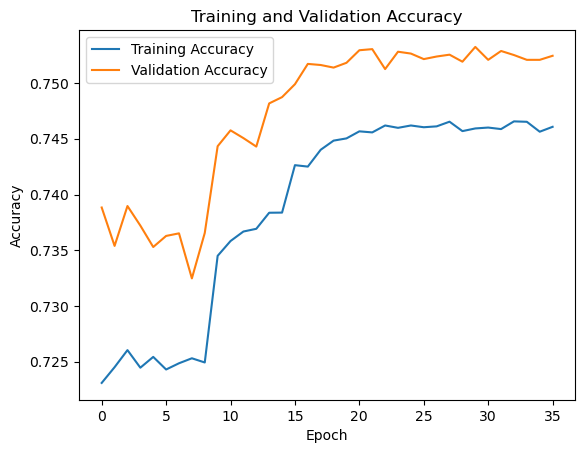

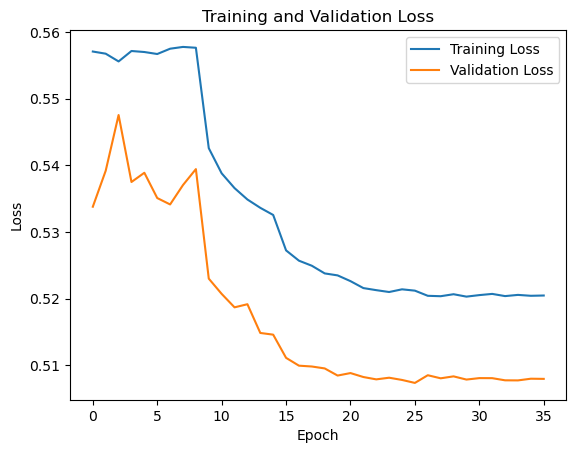

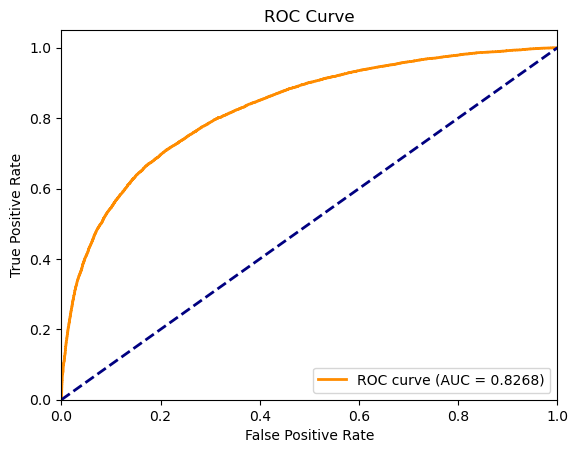

Accuracy for model on test set: 0.7559
AUC score for model on test set: 0.8268


NameError: name 'fc1_neurons' is not defined

In [53]:
# Have to retrain the model with the best parameters because I forgot to save the best performing model.
dr = best_params["dropout_rate"]
lr = best_params["learning_rate"]
l2 = best_params["l2_lambda"]
fc1 = int(best_params["fc1_neurons"])
fc2 = int(best_params["fc2_neurons"])
fc3 = int(best_params["fc3_neurons"])
fc4 = int(best_params["fc4_neurons"])
fc5 = int(best_params["fc5_neurons"])

activation_functions = ['leaky_relu', 'sigmoid', 'tanh']
activation_function_idx = int(best_params['activation_idx'])
activation_function = activation_functions[activation_function_idx]

#(self, dropout_rate, fc1_neurons, fc2_neurons, fc3_neurons, fc4_neurons, fc5_neurons, activation_function):

# Initialize the Model
model = FCN_BC_Bayes2Complex(dropout_rate = dr, fc1_neurons = fc1, fc2_neurons = fc2,
                             fc3_neurons = fc3, fc4_neurons = fc4, fc5_neurons = fc5,
                             activation_function = activation_function)

pytorch_optimizer = optim.Adam(model.parameters(), lr=lr,  weight_decay=l2)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(pytorch_optimizer, mode='max', factor=0.1, patience=5, verbose=True)

analyze_model(model, criterion, pytorch_optimizer, scheduler, 
              train_loader, val_loader, test_loader, num_epochs, patience, train = 'yes')

In [54]:
model_filename = f"ComplexModel_BO_{activation_function}_dr{dr}_lr{lr}_Neurons{fc1}_{fc2}_{fc3}_{fc4}_{fc5}.pt"
torch.save(model.state_dict(), model_filename)

# Data Rescaling

In [ ]:
X_train   = torch.tensor(np.array(hf.get('X_train')), dtype=torch.float32)
X_val     = torch.tensor(np.array(hf.get('X_val')), dtype=torch.float32)
X_test    = torch.tensor(np.array(hf.get('X_test')), dtype=torch.float32)

# Separate categorical and continuous features
cat_features_train = X_train[:, :18]
cont_features_train = X_train[:, 18:]

cat_features_val = X_val[:, :18]
cont_features_val = X_val[:, 18:]

cat_features_test = X_test[:, :18]
cont_features_test = X_test[:, 18:]

# Create masks for non-zero continuous features
cont_nonzero_train = cont_features_train != 0
cont_nonzero_val = cont_features_val != 0
cont_nonzero_test = cont_features_test != 0

# Scale only non-zero continuous features
mean = torch.mean(cont_features_train[cont_nonzero_train])
std = torch.std(cont_features_train[cont_nonzero_train])

cont_features_train[cont_nonzero_train] = (cont_features_train[cont_nonzero_train] - mean) / std
cont_features_val[cont_nonzero_val] = (cont_features_val[cont_nonzero_val] - mean) / std
cont_features_test[cont_nonzero_test] = (cont_features_test[cont_nonzero_test] - mean) / std

# Combine categorical and continuous features back
X_train = torch.cat((cat_features_train, cont_features_train), dim=1)
X_val = torch.cat((cat_features_val, cont_features_val), dim=1)
X_test = torch.cat((cat_features_test, cont_features_test), dim=1)

# create TensorDatasets and DataLoaders
train_dataset = TensorDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataset = TensorDataset(X_val, Y_val)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_dataset = TensorDataset(X_test, Y_test)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [ ]:
print(X_train)

In [11]:
# Renaming the datasets to make a bit more sense to me.
X_train, Y_train = reg_train, sig_train
X_val, Y_val = reg_val, sig_val
X_test, Y_test = reg_test, sig_test

In [ ]:
# Renaming the datasets to make a bit more sense to me.
X_train, Y_train = reg_train, sig_train
X_val, Y_val = reg_val, sig_val
X_test, Y_test = reg_test, sig_test

# Separate categorical and continuous features
cat_features_train = X_train[:, :18]
cont_features_train = X_train[:, 18:]

cat_features_val = X_val[:, :18]
cont_features_val = X_val[:, 18:]

cat_features_test = X_test[:, :18]
cont_features_test = X_test[:, 18:]

# Compute the mean and standard deviation of the training set
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

# Normalize the training set
X_train = (X_train - mean) / std

# Normalize the validation set and test set using the same mean and std as the training set
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

# Define the dataset and dataloaders
train_dataset = TensorDataset(torch.Tensor(X_train), torch.Tensor(Y_train))
val_dataset = TensorDataset(torch.Tensor(X_val), torch.Tensor(Y_val))
test_dataset = TensorDataset(torch.Tensor(X_test), torch.Tensor(Y_test))

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)